In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load data from your CSVs

def load_yfinance_csv(path, asset_name):
    df = pd.read_csv(path)
    df = df.iloc[2:].copy()
    df.rename(columns={"Price": "Date"}, inplace=True)
    df = df[["Date", "Close"]].copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df[asset_name] = pd.to_numeric(df["Close"], errors="coerce")
    df = df[["Date", asset_name]].dropna()
    return df


# 1. Load V and MA
v = load_yfinance_csv("V_daily.csv", "V")
ma = load_yfinance_csv("MA_daily.csv", "MA")

df = pd.merge(v, ma, on="Date", how="inner")
df = df.sort_values("Date").reset_index(drop=True)

In [3]:
# Compute returns and log prices

df["V"] = pd.to_numeric(df["V"], errors="coerce")
df["MA"] = pd.to_numeric(df["MA"], errors="coerce")

df = df.dropna(subset=["V", "MA"])
df = df[(df["V"] > 0) & (df["MA"] > 0)].copy()
df = df.sort_values("Date").reset_index(drop=True)

df["V_ret"] = df["V"].pct_change()
df["MA_ret"] = df["MA"].pct_change()

df["log_V"] = np.log(df["V"])
df["log_MA"] = np.log(df["MA"])

training_set = df[(df["Date"] >= "2000-01-01") & (df["Date"] < "2020-01-01")].copy().reset_index(drop=True)
test_set = df[df["Date"] >= "2020-01-01"].copy().reset_index(drop=True)

In [4]:
# Hyperparameter testing for lookback

def run_backtest_for_lookback(original_df, lookback, entry_z=2.0, exit_z=0.5):
    """
    Runs the V-MA pairs strategy for one lookback value.
    Returns performance metrics and the full backtest dataframe.
    """

    df = original_df.copy()

    df["beta"] = np.nan
    df["spread"] = np.nan
    df["zscore"] = np.nan

    # Estimate rolling beta, spread, and z-score
    for i in range(lookback, len(df)):
        train = df.iloc[i - lookback:i]

        x = train["log_V"].values
        y = train["log_MA"].values

        beta = np.polyfit(x, y, 1)[0]
        df.loc[i, "beta"] = beta

        train_spread = train["log_MA"] - beta * train["log_V"]
        mu = train_spread.mean()
        sigma = train_spread.std()

        current_spread = df.loc[i, "log_MA"] - beta * df.loc[i, "log_V"]

        df.loc[i, "spread"] = current_spread
        df.loc[i, "zscore"] = 0.0 if sigma == 0 else (current_spread - mu) / sigma

    # Trading position
    df["position"] = 0.0
    current_pos = 0

    for i in range(lookback, len(df)):
        z = df.loc[i, "zscore"]

        if current_pos == 0:
            if z > entry_z:
                current_pos = -1  # short spread: short MA, long V
            elif z < -entry_z:
                current_pos = 1  # long spread: long MA, short V

        elif current_pos == 1:
            if z > -exit_z:
                current_pos = 0

        elif current_pos == -1:
            if z < exit_z:
                current_pos = 0

        df.loc[i, "position"] = current_pos

    # Strategy returns
    df["beta_ffill"] = df["beta"].ffill()
    df["spread_ret"] = df["MA_ret"] - df["beta_ffill"] * df["V_ret"]

    df["position_lag"] = df["position"].shift(1).fillna(0)
    df["strategy_ret"] = df["position_lag"] * df["spread_ret"]
    df["strategy_ret"] = df["strategy_ret"].fillna(0)

    df["equity_curve"] = (1 + df["strategy_ret"]).cumprod()

    # Metrics
    mean_ret = df["strategy_ret"].mean()
    std_ret = df["strategy_ret"].std()

    sharpe = np.nan if std_ret == 0 else np.sqrt(252) * mean_ret / std_ret
    total_return = df["equity_curve"].iloc[-1] - 1

    rolling_max = df["equity_curve"].cummax()
    drawdown = df["equity_curve"] / rolling_max - 1
    max_drawdown = drawdown.min()

    num_trades = (df["position"].diff().abs() > 0).sum()

    return {
        "lookback": lookback,
        "sharpe": sharpe,
        "total_return": total_return,
        "max_drawdown": max_drawdown,
        "num_trades": num_trades,
        "final_equity": df["equity_curve"].iloc[-1],
        "backtest_df": df
    }

In [5]:
results = []

# test for lookback values from a quarter of a trading year to 2
for lb in range(63, 504, 2):
    result = run_backtest_for_lookback(training_set, lookback=lb, entry_z=2.0, exit_z=0.5)

    results.append({
        "lookback": result["lookback"],
        "sharpe": result["sharpe"],
        "total_return": result["total_return"],
        "max_drawdown": result["max_drawdown"],
        "num_trades": result["num_trades"],
        "final_equity": result["final_equity"]
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("sharpe", ascending=False)

results_df

,lookback,sharpe,total_return,max_drawdown,num_trades,final_equity
0,63,0.758719,1.784344,-0.150590,188,2.784344
1,65,0.692049,1.541030,-0.138508,182,2.541030
2,67,0.681583,1.464628,-0.138345,168,2.464628
5,73,0.664266,1.347372,-0.146198,146,2.347372
4,71,0.631778,1.253353,-0.143875,150,2.253353
...,...,...,...,...,...,...
217,497,-0.084020,-0.139373,-0.328939,18,0.860627
215,493,-0.085272,-0.140239,-0.330012,18,0.859761
214,491,-0.085678,-0.140754,-0.330902,18,0.859246
216,495,-0.086472,-0.141854,-0.330410,18,0.858146


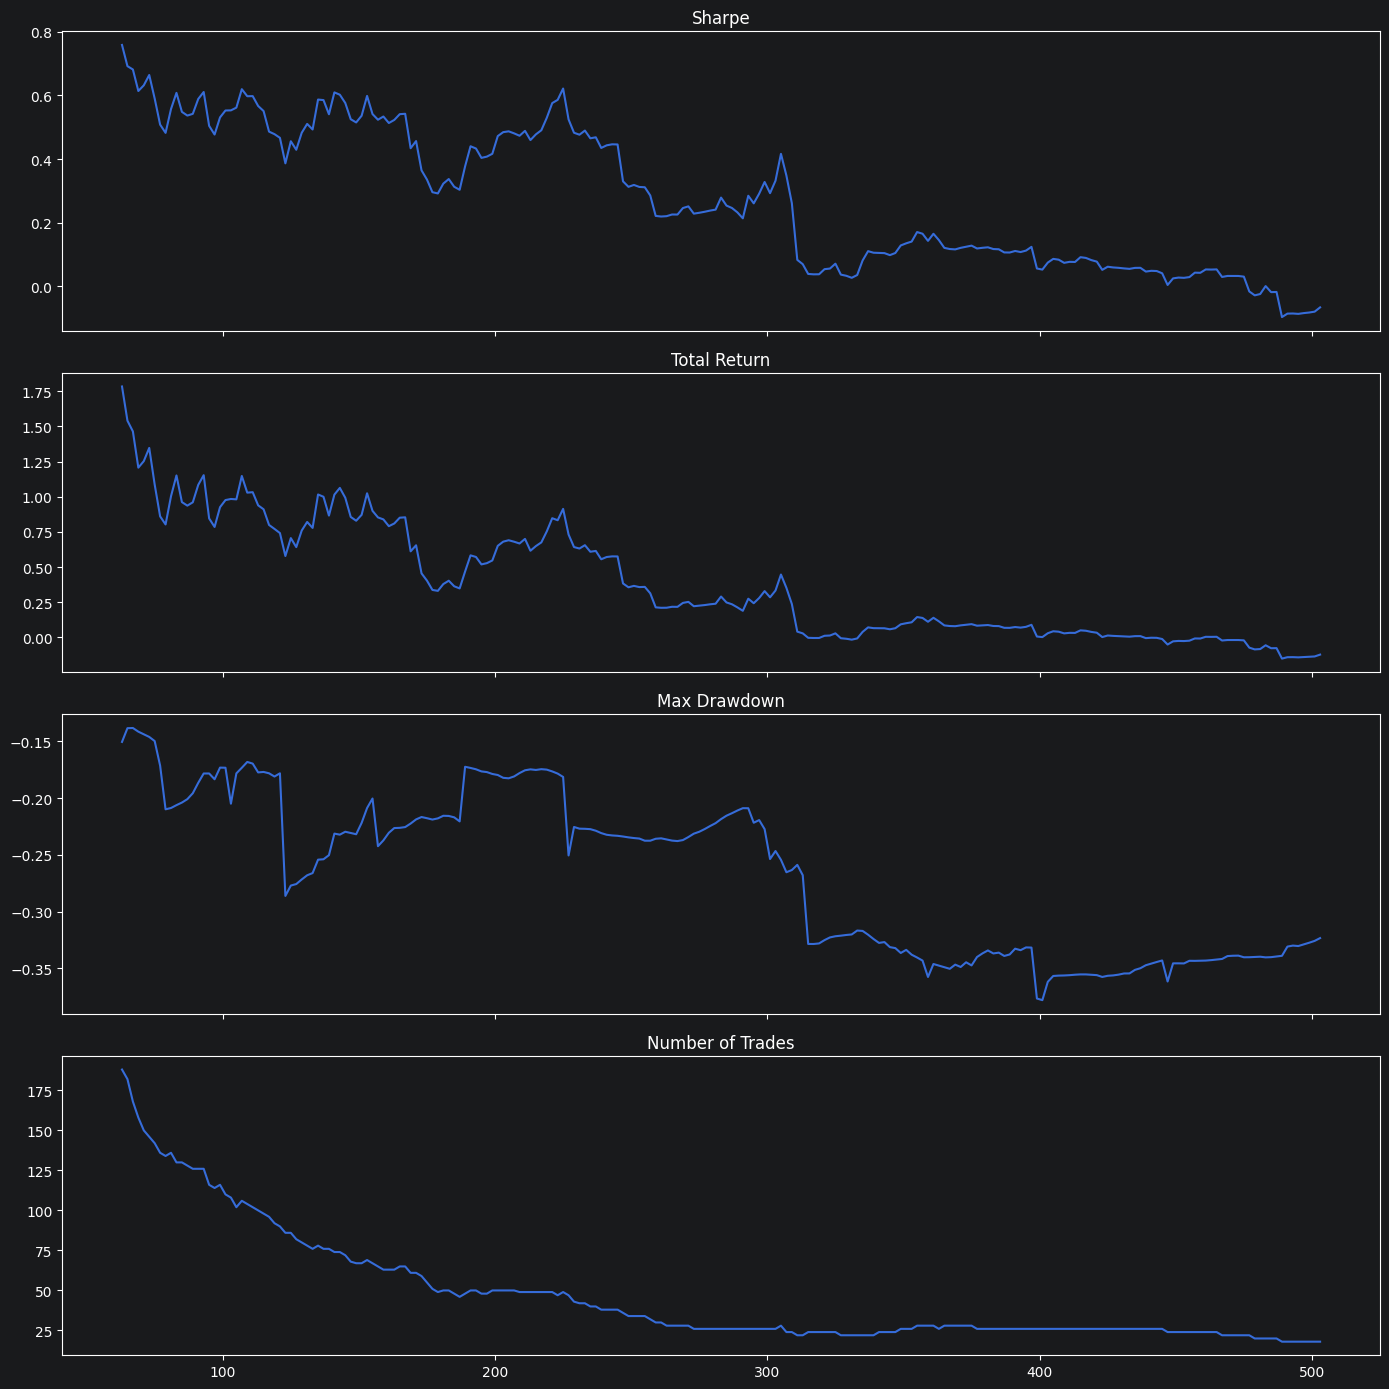

In [6]:
results_df = results_df.sort_values("lookback", ascending=True)

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

axes[0].plot(results_df["lookback"], results_df["sharpe"], label="Sharpe")
axes[0].set_title("Sharpe")

axes[1].plot(results_df["lookback"], results_df["total_return"], label="Total Return")
axes[1].set_title("Total Return")

axes[2].plot(results_df["lookback"], results_df["max_drawdown"], label="Max Drawdown")
axes[2].set_title("Max Drawdown")

axes[3].plot(results_df["lookback"], results_df["num_trades"], label="Number of Trades")
axes[3].set_title("Number of Trades")

plt.tight_layout()
plt.show()

In [9]:
results = []

# test for lookback values from a quarter of a trading year to 2
for lb in range(30, 70, 1):
    result = run_backtest_for_lookback(training_set, lookback=lb, entry_z=2.0, exit_z=0.5)

    results.append({
        "lookback": result["lookback"],
        "sharpe": result["sharpe"],
        "total_return": result["total_return"],
        "max_drawdown": result["max_drawdown"],
        "num_trades": result["num_trades"],
        "final_equity": result["final_equity"]
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("sharpe", ascending=False)

results_df

,lookback,sharpe,total_return,max_drawdown,num_trades,final_equity
6,36,1.049080,3.368078,-0.126298,262,4.368078
0,30,0.974105,2.895061,-0.126884,308,3.895061
20,50,0.956601,2.789853,-0.111461,212,3.789853
19,49,0.956187,2.877298,-0.111275,218,3.877298
12,42,0.953761,2.897992,-0.140253,243,3.897992
11,41,0.945999,2.854325,-0.139218,243,3.854325
21,51,0.945098,2.779880,-0.112110,212,3.779880
5,35,0.930322,2.650892,-0.126062,268,3.650892
18,48,0.930070,2.693829,-0.112629,220,3.693829
3,33,0.929751,2.744668,-0.127466,286,3.744668


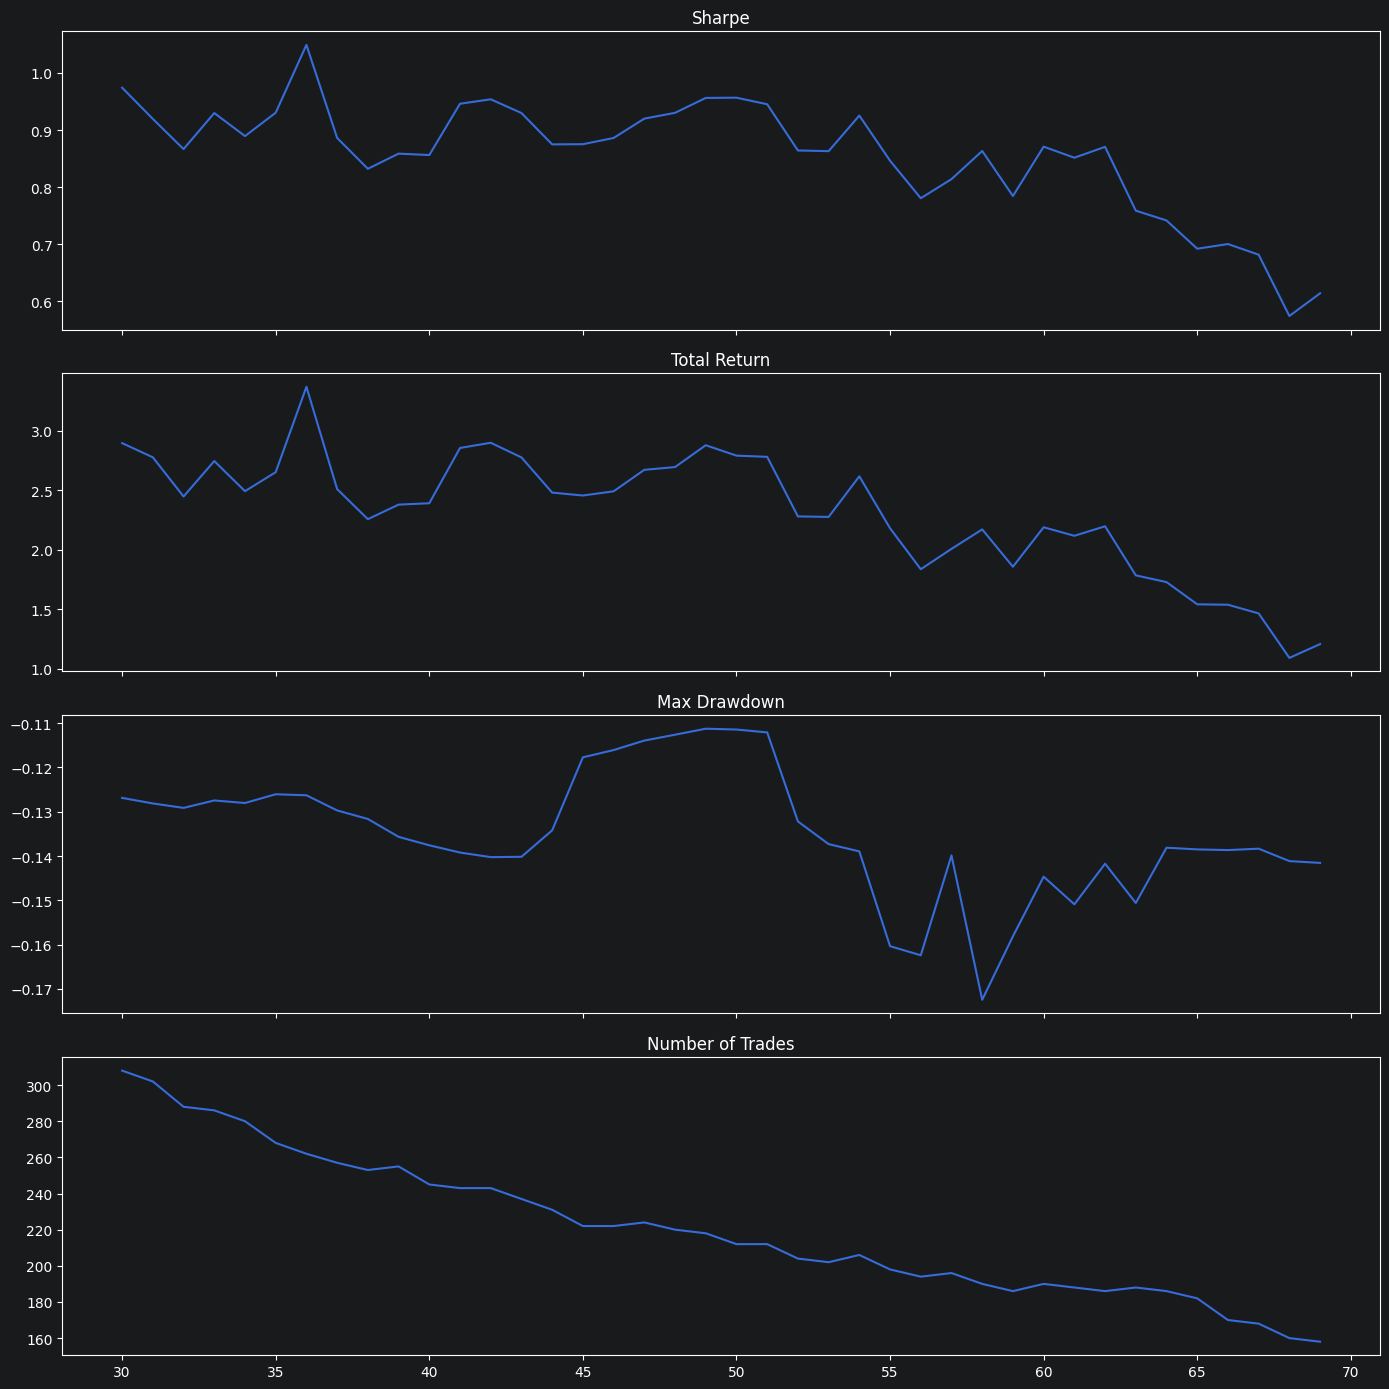

In [10]:
results_df = results_df.sort_values("lookback", ascending=True)

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

axes[0].plot(results_df["lookback"], results_df["sharpe"], label="Sharpe")
axes[0].set_title("Sharpe")

axes[1].plot(results_df["lookback"], results_df["total_return"], label="Total Return")
axes[1].set_title("Total Return")

axes[2].plot(results_df["lookback"], results_df["max_drawdown"], label="Max Drawdown")
axes[2].set_title("Max Drawdown")

axes[3].plot(results_df["lookback"], results_df["num_trades"], label="Number of Trades")
axes[3].set_title("Number of Trades")

plt.tight_layout()
plt.show()

In [14]:
df = results_df.copy()
df = df.sort_values("lookback").reset_index(drop=True)

window = 5

# Smooth local performance
df["sharpe_smooth"] = df["sharpe"].rolling(window, center=True, min_periods=3).mean()
df["return_smooth"] = df["total_return"].rolling(window, center=True, min_periods=3).mean()

# Local instability: high value means Sharpe jumps around nearby
df["sharpe_vol"] = df["sharpe"].rolling(window, center=True, min_periods=3).std()

# Local slope: penalizes regions where smoothed Sharpe is changing quickly
df["sharpe_slope"] = df["sharpe_smooth"].diff().abs()

# Fill edge NaNs
df["sharpe_vol"] = df["sharpe_vol"].fillna(df["sharpe_vol"].median())
df["sharpe_slope"] = df["sharpe_slope"].fillna(df["sharpe_slope"].median())

# Stability-adjusted score
df["stable_score"] = (
    df["sharpe_smooth"]
    - 0.50 * df["sharpe_vol"]
    - 0.25 * df["sharpe_slope"]
)

best = df.sort_values("stable_score", ascending=False).iloc[0]

best

lookback          49.000000
sharpe             0.956187
total_return       2.877298
max_drawdown      -0.111275
num_trades       218.000000
final_equity       3.877298
sharpe_smooth      0.941577
return_smooth      2.762300
sharpe_vol         0.016223
sharpe_slope       0.011815
stable_score       0.930512
Name: 19, dtype: float64

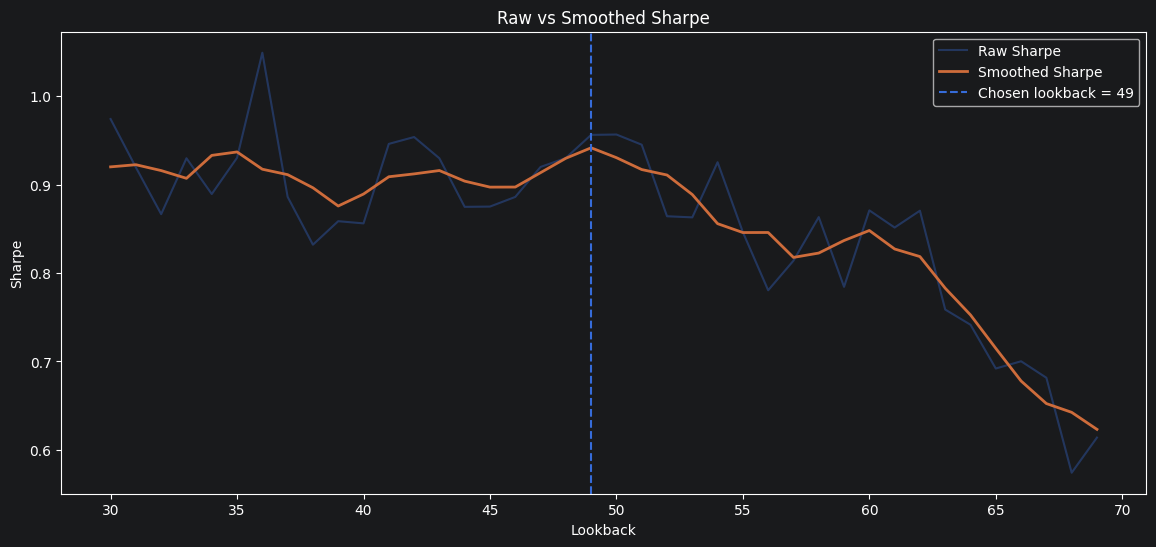

In [15]:
plt.figure(figsize=(14, 6))

plt.plot(df["lookback"], df["sharpe"], alpha=0.35, label="Raw Sharpe")
plt.plot(df["lookback"], df["sharpe_smooth"], linewidth=2, label="Smoothed Sharpe")

plt.axvline(best["lookback"], linestyle="--", label=f"Chosen lookback = {int(best['lookback'])}")

plt.title("Raw vs Smoothed Sharpe")
plt.xlabel("Lookback")
plt.ylabel("Sharpe")
plt.legend()
plt.show()

In [16]:
# Hyperparameter testing for entry and exit z-score thresholds

def run_backtest_for_entry_and_exit(original_df, entry_z, exit_z, lookback=49):
    """
    Runs the V-MA pairs strategy for entry_z and exit_z values.
    Returns performance metrics and the full backtest dataframe.
    """

    df = original_df.copy()

    df["beta"] = np.nan
    df["spread"] = np.nan
    df["zscore"] = np.nan

    # Estimate rolling beta, spread, and z-score
    for i in range(lookback, len(df)):
        train = df.iloc[i - lookback:i]

        x = train["log_V"].values
        y = train["log_MA"].values

        beta = np.polyfit(x, y, 1)[0]
        df.loc[i, "beta"] = beta

        train_spread = train["log_MA"] - beta * train["log_V"]
        mu = train_spread.mean()
        sigma = train_spread.std()

        current_spread = df.loc[i, "log_MA"] - beta * df.loc[i, "log_V"]

        df.loc[i, "spread"] = current_spread
        df.loc[i, "zscore"] = 0.0 if sigma == 0 else (current_spread - mu) / sigma

    # Trading position
    df["position"] = 0.0
    current_pos = 0

    for i in range(lookback, len(df)):
        z = df.loc[i, "zscore"]

        if current_pos == 0:
            if z > entry_z:
                current_pos = -1  # short spread: short MA, long V
            elif z < -entry_z:
                current_pos = 1  # long spread: long MA, short V

        elif current_pos == 1:
            if z > -exit_z:
                current_pos = 0

        elif current_pos == -1:
            if z < exit_z:
                current_pos = 0

        df.loc[i, "position"] = current_pos

    # Strategy returns
    df["beta_ffill"] = df["beta"].ffill()
    df["spread_ret"] = df["MA_ret"] - df["beta_ffill"] * df["V_ret"]

    df["position_lag"] = df["position"].shift(1).fillna(0)
    df["strategy_ret"] = df["position_lag"] * df["spread_ret"]
    df["strategy_ret"] = df["strategy_ret"].fillna(0)

    df["equity_curve"] = (1 + df["strategy_ret"]).cumprod()

    # Metrics
    mean_ret = df["strategy_ret"].mean()
    std_ret = df["strategy_ret"].std()

    sharpe = np.nan if std_ret == 0 else np.sqrt(252) * mean_ret / std_ret
    total_return = df["equity_curve"].iloc[-1] - 1

    rolling_max = df["equity_curve"].cummax()
    drawdown = df["equity_curve"] / rolling_max - 1
    max_drawdown = drawdown.min()

    num_trades = (df["position"].diff().abs() > 0).sum()

    return {
        "entry_z": entry_z,
        "exit_z": exit_z,
        "sharpe": sharpe,
        "total_return": total_return,
        "max_drawdown": max_drawdown,
        "num_trades": num_trades,
        "final_equity": df["equity_curve"].iloc[-1],
        "backtest_df": df
    }

In [17]:
results = []

# Test for entry and exit z-values

for entry_z in np.round(np.arange(1.0, 3.0, 0.1), 2):
    for exit_z in np.round(np.arange(0.5, 2.0, 0.1), 2):

        if exit_z >= entry_z:
            continue

        result = run_backtest_for_entry_and_exit(training_set, entry_z=entry_z, exit_z=exit_z)

        results.append({
            "entry_z": entry_z,
            "exit_z": exit_z,
            "sharpe": result["sharpe"],
            "total_return": result["total_return"],
            "max_drawdown": result["max_drawdown"],
            "num_trades": result["num_trades"],
            "final_equity": result["final_equity"]
        })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("sharpe", ascending=False)

results_df

,entry_z,exit_z,sharpe,total_return,max_drawdown,num_trades,final_equity
41,1.5,1.1,1.246925,4.343974,-0.110264,416,5.343974
87,1.9,1.1,1.246703,3.672073,-0.110264,296,4.672073
88,1.9,1.2,1.215867,3.426058,-0.110264,308,4.426058
17,1.2,1.1,1.212902,5.171240,-0.133492,582,6.171240
42,1.5,1.2,1.207880,3.990674,-0.110264,430,4.990674
...,...,...,...,...,...,...,...
180,2.5,1.5,0.643167,0.781414,-0.119416,166,1.781414
149,2.3,1.4,0.637496,0.850592,-0.110264,198,1.850592
184,2.5,1.9,0.626783,0.699570,-0.126732,182,1.699570
181,2.5,1.6,0.625806,0.740074,-0.119136,170,1.740074


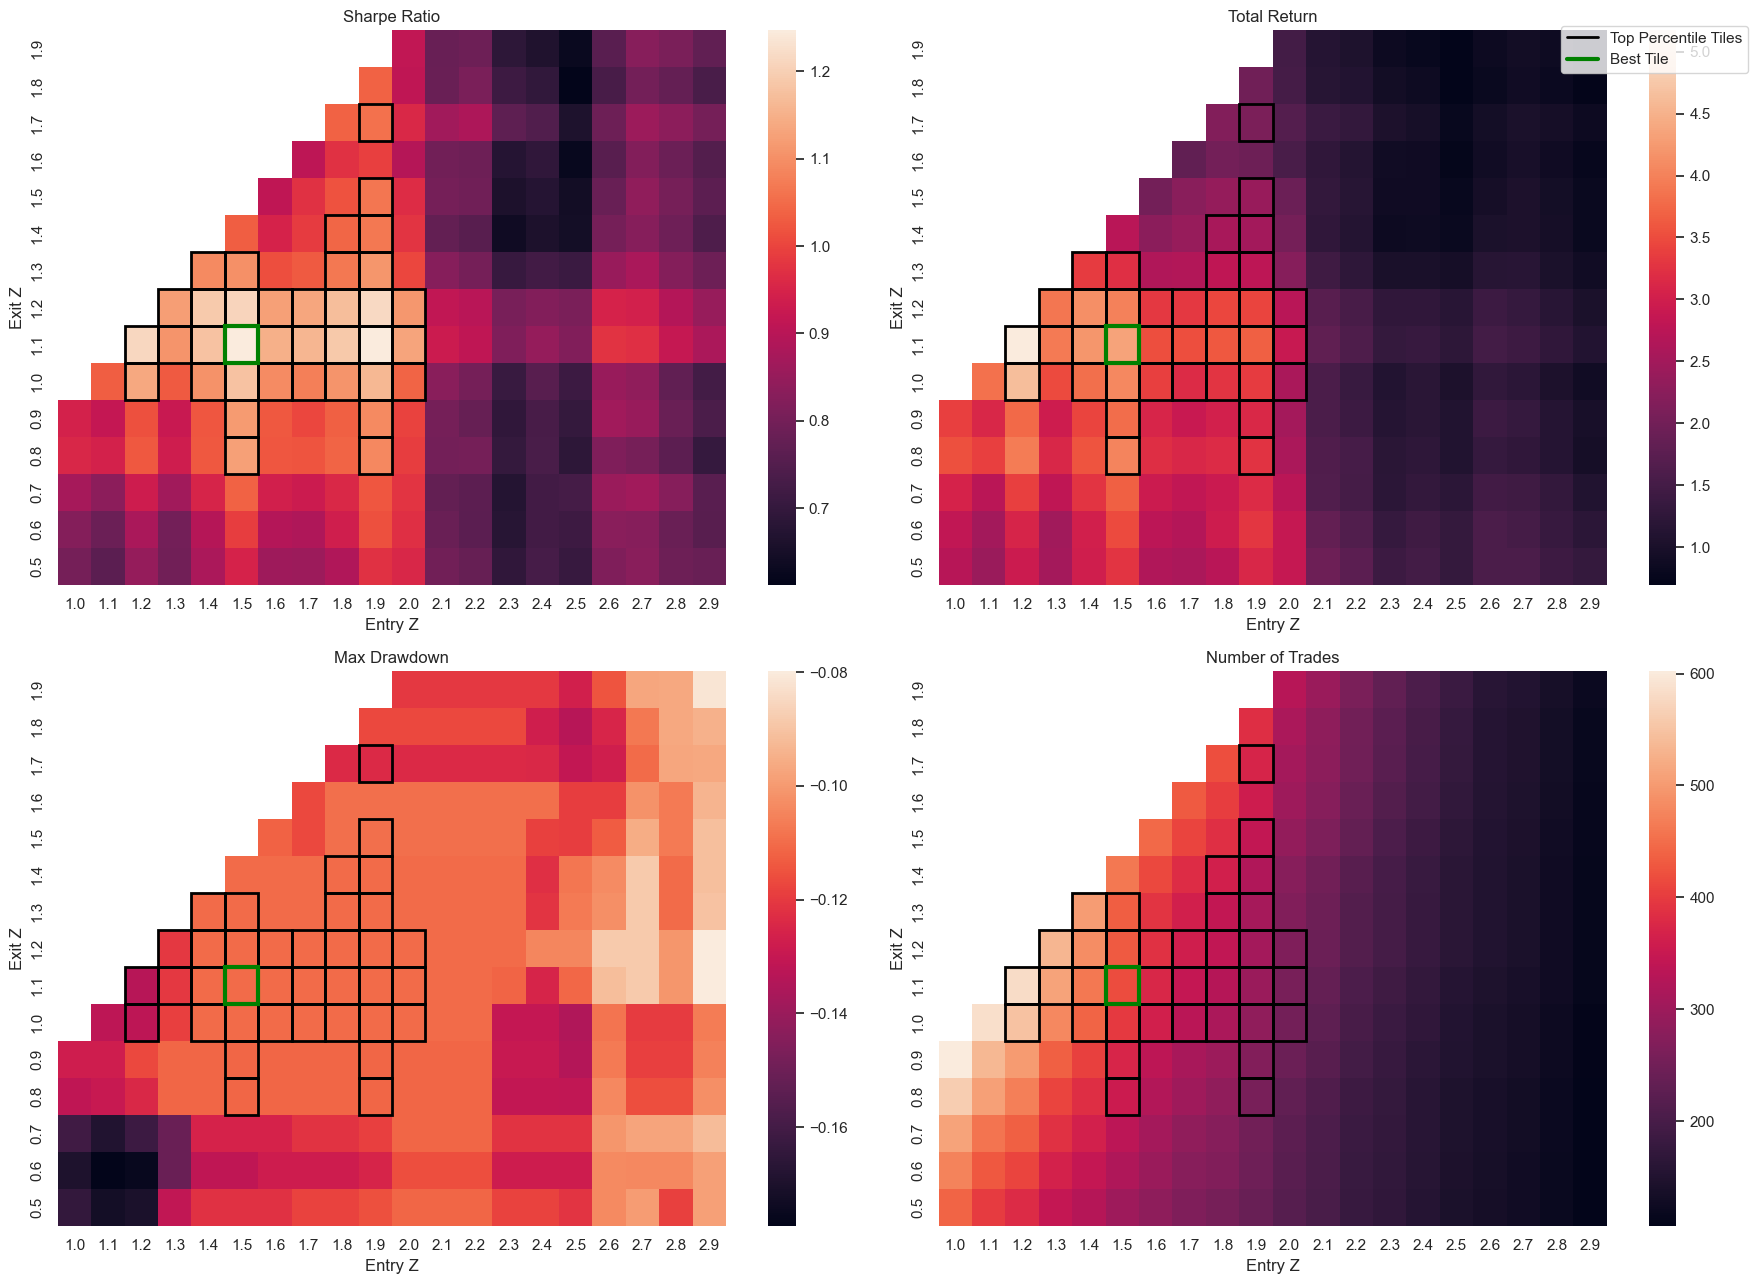

In [18]:
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

sns.set_theme(style="white")

results_df = results_df.copy()
results_df["risk_score"] = results_df["sharpe"] - 0.5 * results_df["max_drawdown"].abs()

sharpe_pivot = results_df.pivot(index="exit_z", columns="entry_z", values="sharpe")
return_pivot = results_df.pivot(index="exit_z", columns="entry_z", values="total_return")
drawdown_pivot = results_df.pivot(index="exit_z", columns="entry_z", values="max_drawdown")
trades_pivot = results_df.pivot(index="exit_z", columns="entry_z", values="num_trades")
risk_pivot = results_df.pivot(index="exit_z", columns="entry_z", values="risk_score")

sharpe_pivot = sharpe_pivot.sort_index(ascending=False)
return_pivot = return_pivot.sort_index(ascending=False)
drawdown_pivot = drawdown_pivot.sort_index(ascending=False)
trades_pivot = trades_pivot.sort_index(ascending=False)
risk_pivot = risk_pivot.sort_index(ascending=False)

best_sharpe_exit, best_sharpe_entry = sharpe_pivot.stack().idxmax()
best_sharpe_row = sharpe_pivot.index.get_loc(best_sharpe_exit)
best_sharpe_col = sharpe_pivot.columns.get_loc(best_sharpe_entry)

threshold = risk_pivot.stack().quantile(0.85)
eligible_mask = (risk_pivot >= threshold) & (~risk_pivot.isna())

top_percentile_cells = []
for r in range(eligible_mask.shape[0]):
    for c in range(eligible_mask.shape[1]):
        if eligible_mask.iat[r, c]:
            top_percentile_cells.append((r, c))


def add_highlights(ax, best_sharpe_row, best_sharpe_col, top_percentile_cells):
    for r, c in top_percentile_cells:
        rect = Rectangle((c, r), 1, 1, fill=False, edgecolor="black", linewidth=2)
        ax.add_patch(rect)

    rect = Rectangle((best_sharpe_col, best_sharpe_row), 1, 1, fill=False, edgecolor="green", linewidth=3)
    ax.add_patch(rect)


fig, axes = plt.subplots(2, 2, figsize=(18, 13))

sns.heatmap(sharpe_pivot, annot=False, ax=axes[0, 0], cbar=True)
axes[0, 0].set_title("Sharpe Ratio")
axes[0, 0].set_xlabel("Entry Z")
axes[0, 0].set_ylabel("Exit Z")
add_highlights(axes[0, 0], best_sharpe_row, best_sharpe_col, top_percentile_cells)

sns.heatmap(return_pivot, annot=False, ax=axes[0, 1], cbar=True)
axes[0, 1].set_title("Total Return")
axes[0, 1].set_xlabel("Entry Z")
axes[0, 1].set_ylabel("Exit Z")
add_highlights(axes[0, 1], best_sharpe_row, best_sharpe_col, top_percentile_cells)

sns.heatmap(drawdown_pivot, annot=False, ax=axes[1, 0], cbar=True)
axes[1, 0].set_title("Max Drawdown")
axes[1, 0].set_xlabel("Entry Z")
axes[1, 0].set_ylabel("Exit Z")
add_highlights(axes[1, 0], best_sharpe_row, best_sharpe_col, top_percentile_cells)

sns.heatmap(trades_pivot, annot=False, ax=axes[1, 1], cbar=True)
axes[1, 1].set_title("Number of Trades")
axes[1, 1].set_xlabel("Entry Z")
axes[1, 1].set_ylabel("Exit Z")
add_highlights(axes[1, 1], best_sharpe_row, best_sharpe_col, top_percentile_cells)

# Legend
legend_handles = [
    Line2D([0], [0], color="black", lw=2, label="Top Percentile Tiles"),
    Line2D([0], [0], color="green", lw=3, label="Best Tile")
]
fig.legend(handles=legend_handles, loc="upper right", bbox_to_anchor=(0.98, 0.98))

plt.tight_layout()
plt.show()

In [20]:
def run_backtest_for_e_stop(original_df, e_stop, entry_z=1.5, exit_z=0.1, lookback=49):
    """
    Runs the V-MA pairs strategy for e_stop values.
    Returns performance metrics and the full backtest dataframe.
    """

    df = original_df.copy()

    df["beta"] = np.nan
    df["spread"] = np.nan
    df["zscore"] = np.nan

    # Estimate rolling beta, spread, and z-score
    for i in range(lookback, len(df)):
        train = df.iloc[i - lookback:i]

        x = train["log_V"].values
        y = train["log_MA"].values

        beta = np.polyfit(x, y, 1)[0]
        df.loc[i, "beta"] = beta

        train_spread = train["log_MA"] - beta * train["log_V"]
        mu = train_spread.mean()
        sigma = train_spread.std()

        current_spread = df.loc[i, "log_MA"] - beta * df.loc[i, "log_V"]

        df.loc[i, "spread"] = current_spread
        df.loc[i, "zscore"] = 0.0 if sigma == 0 else (current_spread - mu) / sigma

    # Trading position
    df["position"] = 0.0
    current_pos = 0

    for i in range(lookback, len(df)):
        z = df.loc[i, "zscore"]

        if current_pos == 0:
            if z > entry_z:
                current_pos = -1  # short spread: short MA, long V
            elif z < -entry_z:
                current_pos = 1  # long spread: long MA, short V

        elif current_pos == 1:
            if z > -exit_z or z < -e_stop:
                current_pos = 0

        elif current_pos == -1:
            if z < exit_z or z > e_stop:
                current_pos = 0

        df.loc[i, "position"] = current_pos

    # Strategy returns
    df["beta_ffill"] = df["beta"].ffill()
    df["spread_ret"] = df["MA_ret"] - df["beta_ffill"] * df["V_ret"]

    df["position_lag"] = df["position"].shift(1).fillna(0)
    df["strategy_ret"] = df["position_lag"] * df["spread_ret"]
    df["strategy_ret"] = df["strategy_ret"].fillna(0)

    df["equity_curve"] = (1 + df["strategy_ret"]).cumprod()

    # Metrics
    mean_ret = df["strategy_ret"].mean()
    std_ret = df["strategy_ret"].std()

    sharpe = np.nan if std_ret == 0 else np.sqrt(252) * mean_ret / std_ret
    total_return = df["equity_curve"].iloc[-1] - 1

    rolling_max = df["equity_curve"].cummax()
    drawdown = df["equity_curve"] / rolling_max - 1
    max_drawdown = drawdown.min()

    num_trades = (df["position"].diff().abs() > 0).sum()

    return {
        "e_stop": e_stop,
        "sharpe": sharpe,
        "total_return": total_return,
        "max_drawdown": max_drawdown,
        "num_trades": num_trades,
        "final_equity": df["equity_curve"].iloc[-1],
        "backtest_df": df
    }

In [21]:
e_stop_values = np.round(np.arange(1.5, 4.0, 0.1), 2)

results = []
entry_z = 1.5
exit_z = 1.1

# Hyperparameter tune an e_stop variable

for e_stop in e_stop_values:

    if e_stop <= entry_z:
        continue

    result = run_backtest_for_e_stop(
        training_set,
        lookback=49,
        entry_z=entry_z,
        exit_z=exit_z,
        e_stop=e_stop
    )

    results.append({
        "e_stop": e_stop,
        "sharpe": result["sharpe"],
        "total_return": result["total_return"],
        "max_drawdown": result["max_drawdown"],
        "num_trades": result["num_trades"],
        "final_equity": result["final_equity"]
    })

e_stop_results_df = pd.DataFrame(results)
e_stop_results_df = e_stop_results_df.sort_values("sharpe", ascending=False)

e_stop_results_df

,e_stop,sharpe,total_return,max_drawdown,num_trades,final_equity
23,3.9,1.152229,3.534093,-0.112569,444,4.534093
18,3.4,1.149047,3.468916,-0.110264,480,4.468916
19,3.5,1.148820,3.510912,-0.116620,470,4.510912
22,3.8,1.130941,3.396677,-0.118896,452,4.396677
17,3.3,1.120072,3.264869,-0.110264,488,4.264869
16,3.2,1.119064,3.248377,-0.110264,496,4.248377
20,3.6,1.107446,3.216276,-0.116620,464,4.216276
21,3.7,1.105002,3.213072,-0.118896,454,4.213072
15,3.1,1.087575,3.059112,-0.110264,520,4.059112
14,3.0,1.064409,2.918590,-0.110264,528,3.918590


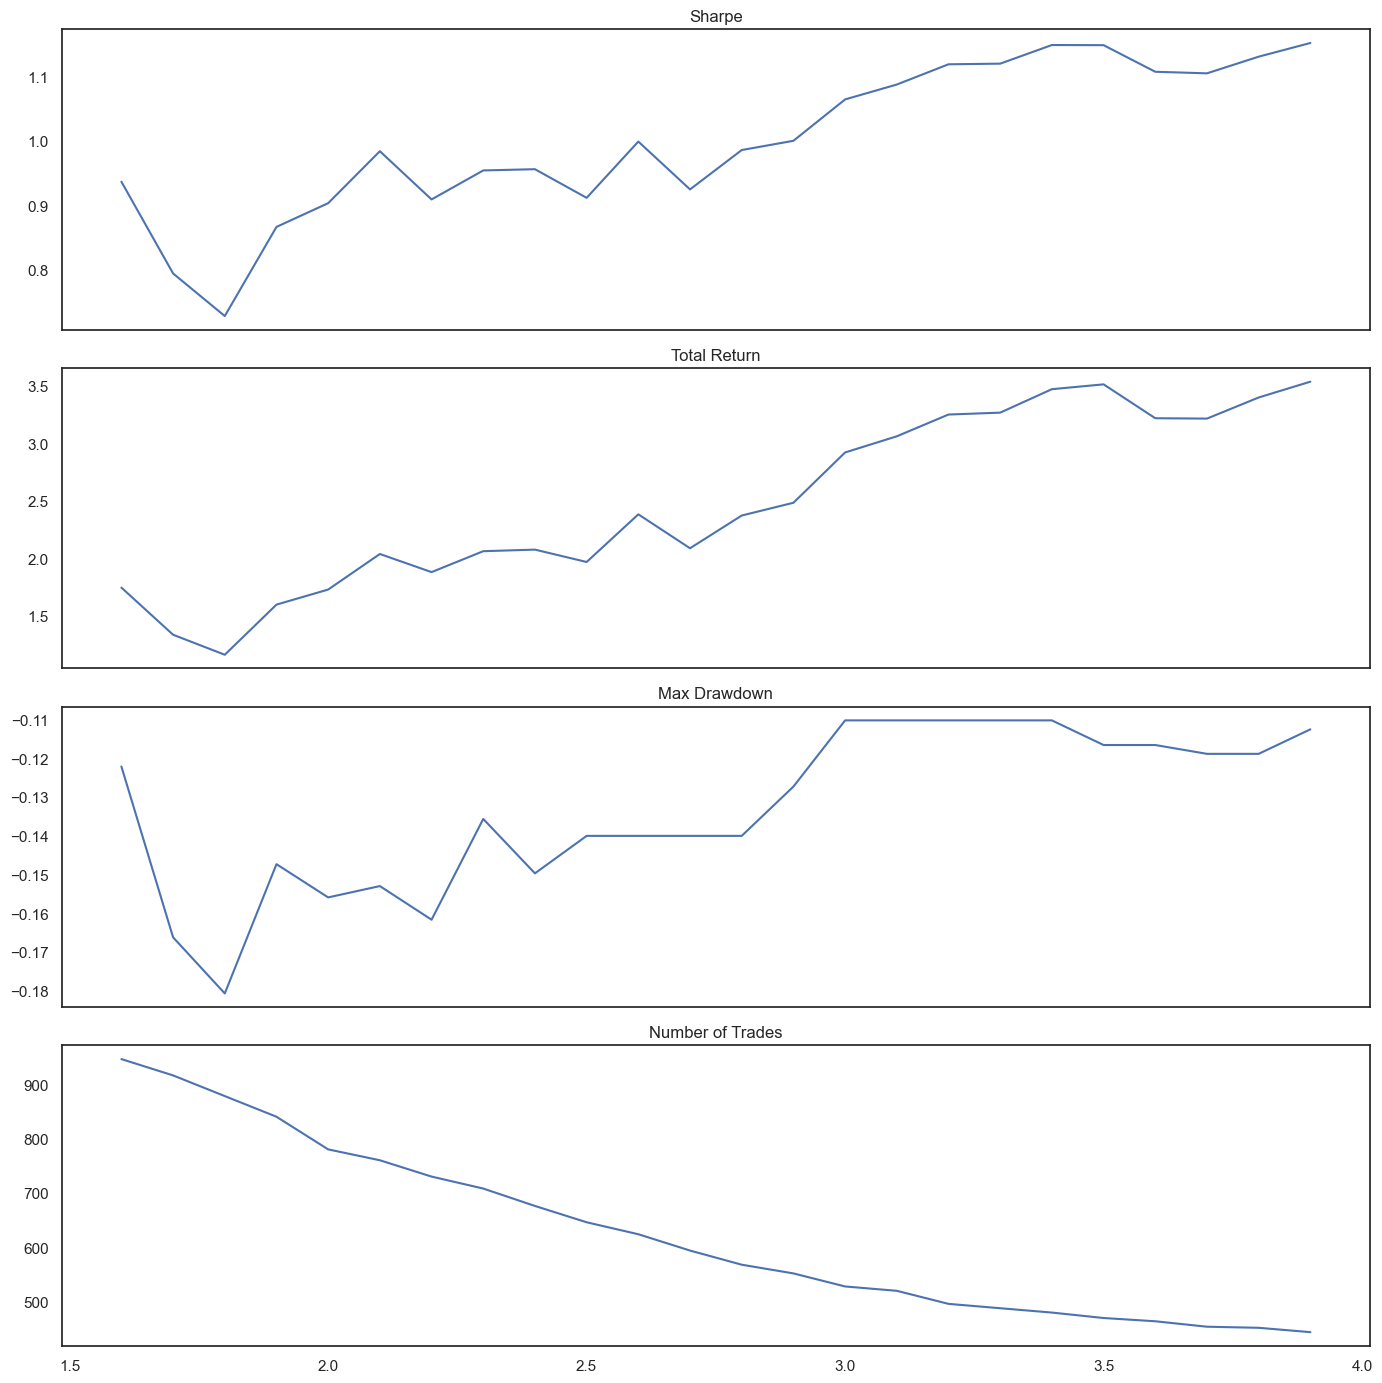

In [22]:
results_df = e_stop_results_df.sort_values("e_stop", ascending=True)

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

axes[0].plot(results_df["e_stop"], results_df["sharpe"], label="Sharpe")
axes[0].set_title("Sharpe")

axes[1].plot(results_df["e_stop"], results_df["total_return"], label="Total Return")
axes[1].set_title("Total Return")

axes[2].plot(results_df["e_stop"], results_df["max_drawdown"], label="Max Drawdown")
axes[2].set_title("Max Drawdown")

axes[3].plot(results_df["e_stop"], results_df["num_trades"], label="Number of Trades")
axes[3].set_title("Number of Trades")

plt.tight_layout()
plt.show()